# 24 h test: linear against rotational encoder

Companion to `24hrstest_can_linear.py`, `24hrstest_can_rotational.py` and
`24hrstest_shift.py`. Two runs are compared, one per encoder; each one visits the
**scale** and the **sample** every 10 min for 24 h and takes a photo there.

Nothing is correlated here: the shift of every photo against the first photo of its
place (`dx`, `dy` in um, positive = right / down in the photo) is read from
`<run>_shift.csv`, so run `24hrstest_shift.py <run>.csv` first. The encoder counts and
the lost-step events come from `<run>.csv`.

1. the shift of the photos, with the lost-step events (4 plots)
2. `dx` of both encoders in one plot, with the compensation zone (2 plots)
3. encoder minus photo: did the encoder see the shift? (2 plots)
4. more: what the compensation saw, where the unseen shift comes from, numbers

In [1]:
import csv
import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

# run CSV and um per encoder count of each encoder. The sign turns the counts into the
# direction of dx (+ = picture to the right): the linear encoder counts up with the
# motor steps, the rotational one counts down (see "sign of the rotational encoder").
RUNS = {
    "linear": ("24hrstest_can_x_20261003_110333.csv", +1.95),
    "rotational": ("24hrstest_can_rotational_x_20261004_151450.csv", -0.25),
}
PLACES = ("scale", "sample")
OUT_DIR = "24hrstest_compare_plots"   # the plots are saved here (next to the CSVs), None = not saved

# the CSVs are in the folder the tests were started in: here or a folder above
DATA_DIR = next(d for p in (Path.cwd(), *Path.cwd().parents) for d in (p, p / "encoder_test_data")
                if (d / RUNS["linear"][0]).exists())

COLOR = {"dx": "#e34948", "dy": "#2a78d6", "lost": "#008300",
         "linear": "#eb6834", "rotational": "#4a3aa7", "zone": "#8a8984"}
plt.rcParams.update({
    "figure.figsize": (11, 4), "figure.dpi": 110, "savefig.dpi": 150,
    "lines.linewidth": 1.6, "lines.markersize": 5,
    "axes.spines.top": False, "axes.spines.right": False, "axes.axisbelow": True,
    "axes.grid": True, "grid.color": "#e6e5e0", "grid.linewidth": 0.7,
    "axes.titlesize": 11, "axes.titlelocation": "left", "legend.frameon": False,
})

## Data

`enc` is what the encoder says about the same thing as `dx`: the raw count against the
raw count at the first photo of the place, times um per count.

In [2]:
def load(csv_name, um_per_count):
    """One run: the lost-step events and, per place, the photos as arrays."""
    with open(DATA_DIR / csv_name, newline="") as f:
        lines = f.readlines()
    header = "".join(l for l in lines if l.startswith("#"))
    rows = list(csv.DictReader(l for l in lines if not l.startswith("#")))
    with open(DATA_DIR / csv_name.replace(".csv", "_shift.csv"), newline="") as f:
        shifts = list(csv.DictReader(f))

    t_start = np.datetime64(min(r["time_iso"] for r in rows))   # as in 24hrstest_shift.py

    def hours(time_iso):
        return (np.datetime64(time_iso) - t_start) / np.timedelta64(1, "h")

    by_visit = {r["visit"]: r for r in rows}
    comp_counts = int(re.search(r"comp_counts=(\d+)", header).group(1))
    run = {
        "um_per_count": um_per_count,
        "comp_um": comp_counts * abs(um_per_count),   # half width of the compensation zone
        # the move in which the steps were lost; the photo of that visit is taken
        # right after the recovery
        "lost": [dict(hours=hours(r["xMoveStart"]), place=r["place"], steps=int(r["lostSteps"]))
                 for r in rows if r["event"]],
    }
    for place in PLACES:
        s = [r for r in shifts if r["place"] == place]
        raw = np.array([float(r["rawCounts"]) for r in s])
        event = np.array([bool(r["event"]) for r in s])
        run[place] = {
            "hours": np.array([float(r["hours"]) for r in s]),
            "dx": np.array([float(r["dx_um"]) for r in s]),
            "dy": np.array([float(r["dy_um"]) for r in s]),
            "enc": (raw - raw[0]) * um_per_count,
            # how far off the encoder was on arrival, before any correction, against
            # the first arrival at the place (which is what the compensation looks at)
            "drift": np.array([float(by_visit[r["visit"]]["encDriftCounts"]) for r in s]) * um_per_count,
            "event": event,
            # corrected because the encoder was out of the zone, no steps lost
            "comp": np.array([float(r["compSteps"]) != 0 for r in s]) & ~event,
        }
    return run


runs = {name: load(*args) for name, args in RUNS.items()}
for name, run in runs.items():
    print(f"{name:<11} {RUNS[name][0]}: {len(run['scale']['dx'])} scale + "
          f"{len(run['sample']['dx'])} sample photos, {len(run['lost'])} lost-step events, "
          f"compensation zone +-{run['comp_um']:.2f} um")


def new_plot(title, ylabel):
    fig, ax = plt.subplots()
    ax.axhline(0, color="#52514e", lw=0.8)
    ax.set_title(title, pad=26)   # room for the legend between the title and the axes
    ax.set(ylabel=ylabel, xlabel="time since the start of the run [h]", xlim=(0, 24.3))
    ax.set_xticks(range(0, 25, 2))
    return fig, ax


def mark_lost(ax, run):
    """A green dashed line at every lost-step event of the run."""
    for i, e in enumerate(run["lost"]):
        ax.axvline(e["hours"], color=COLOR["lost"], ls="--", lw=1.2, zorder=1,
                   label=f"lost steps ({len(run['lost'])} events)" if i == 0 else None)


def finish(fig, ax, name):
    ax.legend(loc="lower left", bbox_to_anchor=(0, 1), borderaxespad=0.2, ncol=5, fontsize=9)
    fig.tight_layout()
    if OUT_DIR:
        (DATA_DIR / OUT_DIR).mkdir(exist_ok=True)
        fig.savefig(DATA_DIR / OUT_DIR / f"{name}.png")
    plt.show()

linear      24hrstest_can_x_20261003_110333.csv: 73 scale + 72 sample photos, 9 lost-step events, compensation zone +-9.75 um
rotational  24hrstest_can_rotational_x_20261004_151450.csv: 73 scale + 72 sample photos, 7 lost-step events, compensation zone +-9.75 um


## 1. Shift of the photos against the first one

One plot per encoder and place: `dx` (red) and `dy` (blue). The green dashed lines are
the lost-step events of the run, at the start of the move in which the steps were
lost. All events of the run are in both plots, also the ones on the way to the other
place. The y axis is not the same in the four plots.

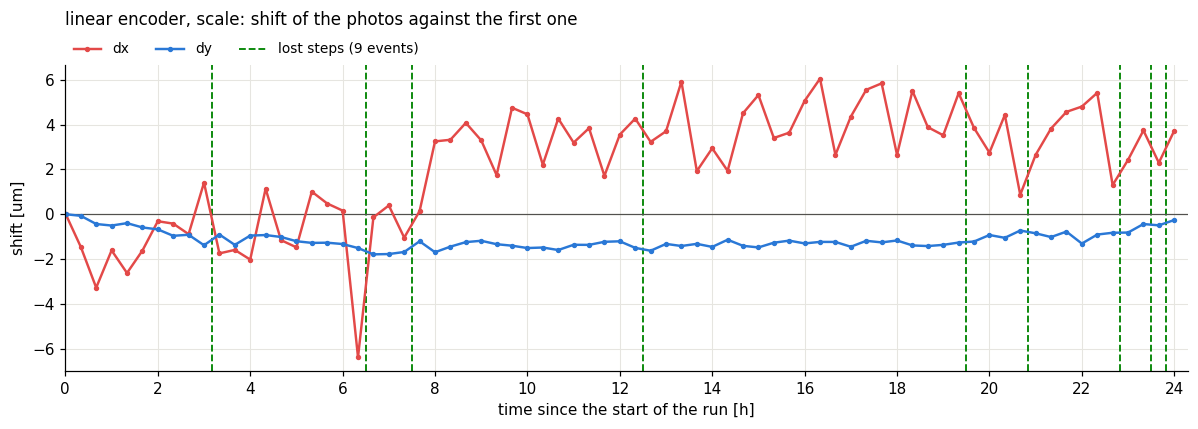

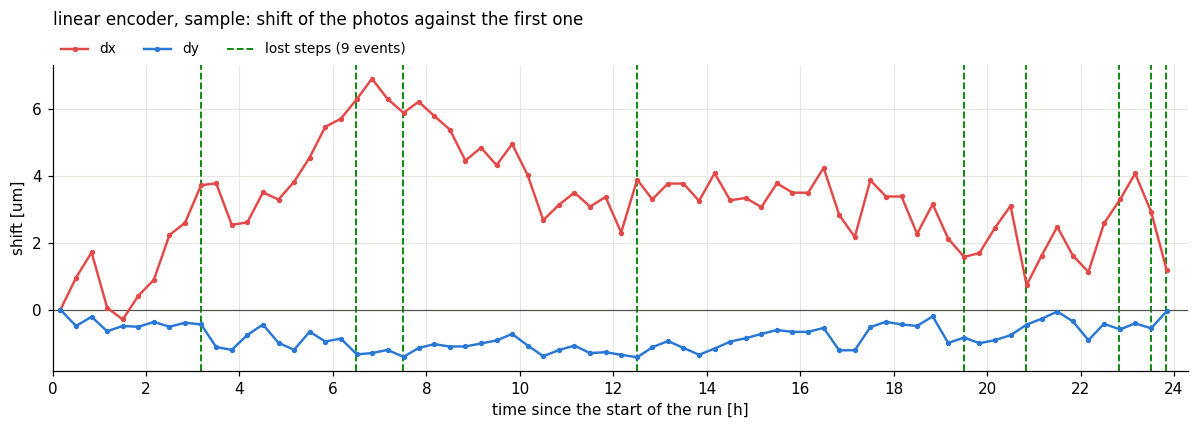

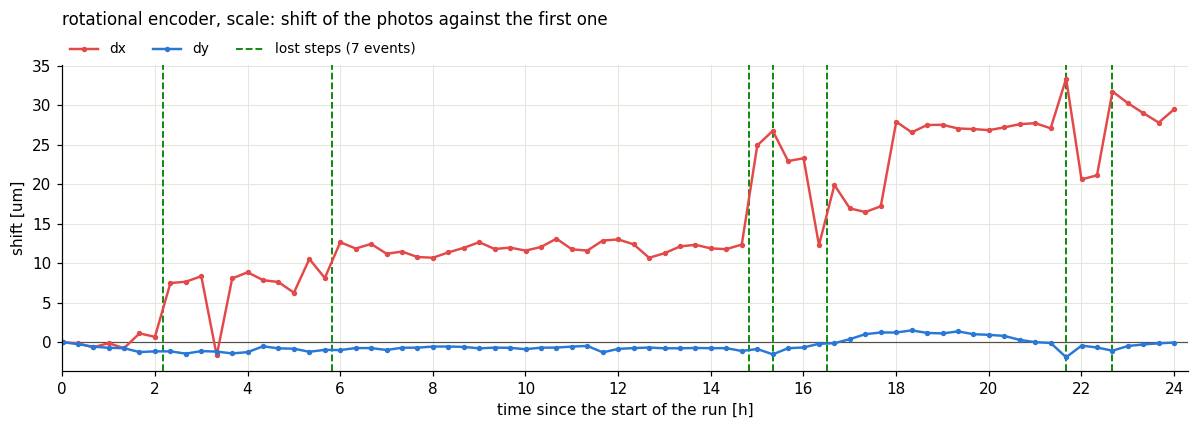

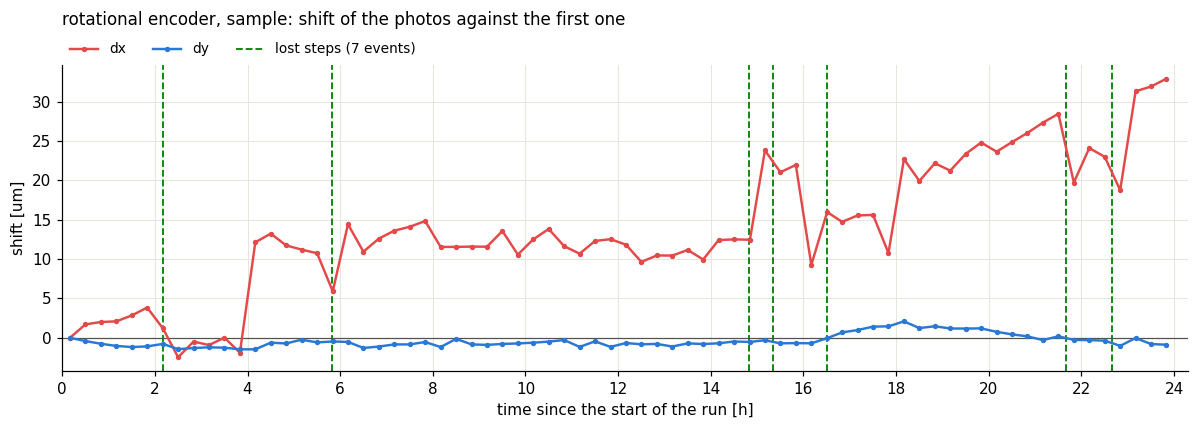

In [3]:
for name, run in runs.items():
    for place in PLACES:
        p = run[place]
        fig, ax = new_plot(f"{name} encoder, {place}: shift of the photos against the first one",
                           "shift [um]")
        ax.plot(p["hours"], p["dx"], ".-", color=COLOR["dx"], label="dx")
        ax.plot(p["hours"], p["dy"], ".-", color=COLOR["dy"], label="dy")
        mark_lost(ax, run)
        finish(fig, ax, f"1_shift_{name}_{place}")

## 2. dx of both encoders, with the compensation zone

The compensation only corrects X when the encoder is more than `comp_counts` off:
5 counts of the linear and 39 counts of the rotational encoder, both 9.75 um. The
zone is drawn around the first photo, like `dx`. The y axis is the same in both plots.

The zone of the test itself is around the encoder count at the *first arrival* at the
place, and that is the move before the first photo. For the rotational run at the
sample the two are 38 counts = 9.5 um apart (see 4.1), so there the real zone is not
centred on `dx = 0`.

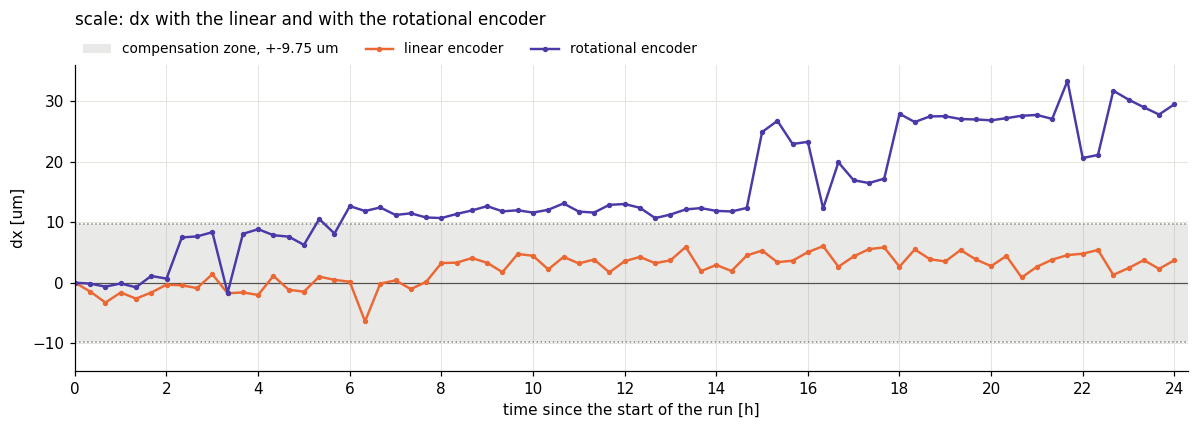

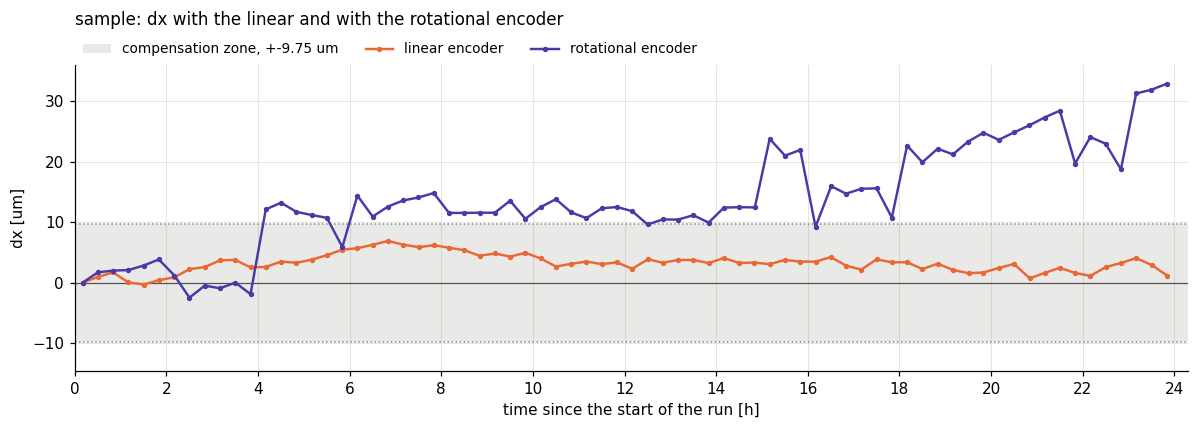

In [4]:
zone = runs["linear"]["comp_um"]
assert all(np.isclose(run["comp_um"], zone) for run in runs.values()), "not the same zone"
top = 1.08 * max(np.abs(run[place]["dx"]).max() for run in runs.values() for place in PLACES)

for place in PLACES:
    fig, ax = new_plot(f"{place}: dx with the linear and with the rotational encoder", "dx [um]")
    ax.axhspan(-zone, zone, color=COLOR["zone"], alpha=0.18, lw=0,
               label=f"compensation zone, +-{zone:.2f} um")
    for edge in (-zone, zone):
        ax.axhline(edge, color=COLOR["zone"], ls=":", lw=1)
    for name, run in runs.items():
        ax.plot(run[place]["hours"], run[place]["dx"], ".-", color=COLOR[name],
                label=f"{name} encoder")
    ax.set_ylim(-1.5 * zone, top)
    finish(fig, ax, f"2_dx_{place}")

## 3. Encoder minus photo: did the encoder see the shift?

`enc - dx`: the raw count against the first photo, times um per count (1.95 um
linear, 0.25 um rotational), minus the shift of the photo. 0 = the encoder reports
exactly what the photo shows; a value that stays away from 0 is a shift of the
picture the encoder does not know about.

### Sign of the rotational encoder

From the scale to the sample the motor goes -296010 steps in both runs. The linear
encoder goes from 0 to -47409 counts on the way, the rotational one from 0 to
+369981: it counts against the steps (-0.8 steps per count), so its counts are taken
with a minus sign here. The cell below checks it with the photos: the change of `dx`
from one photo to the next against the change of the count (a line through 0, over
all pairs of photos where the count changed).

In [5]:
for name, run in runs.items():
    counts = np.concatenate([np.diff(run[p]["enc"]) / run["um_per_count"] for p in PLACES])
    ddx = np.concatenate([np.diff(run[p]["dx"]) for p in PLACES])
    print(f"{name:<11} count changes up to {np.abs(counts).max():.0f}: dx moves "
          f"{(counts * ddx).sum() / (counts ** 2).sum():+.2f} um per count "
          f"(r = {np.corrcoef(counts[counts != 0], ddx[counts != 0])[0, 1]:+.2f}, "
          f"used: {run['um_per_count']:+.2f})")

linear      count changes up to 4: dx moves +0.96 um per count (r = +0.86, used: +1.95)
rotational  count changes up to 44: dx moves -0.27 um per count (r = -0.89, used: -0.25)


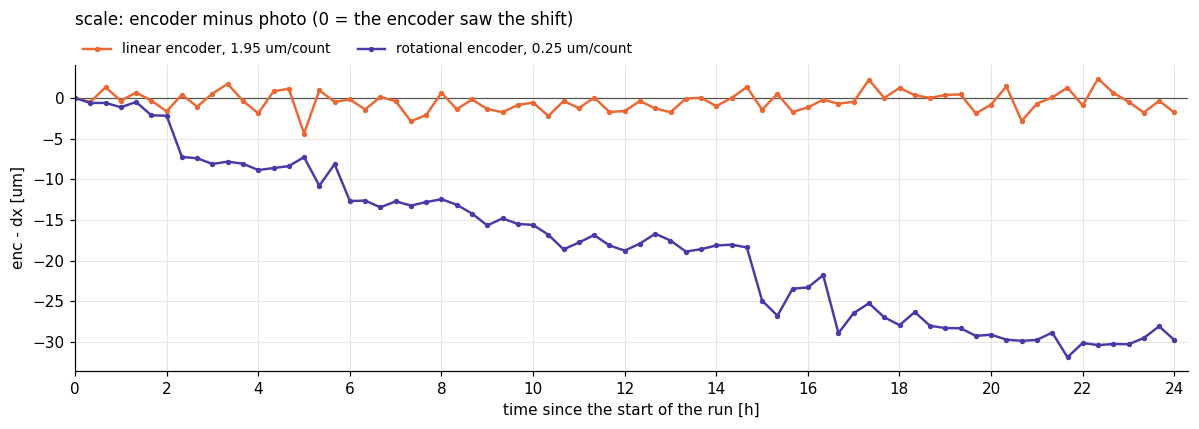

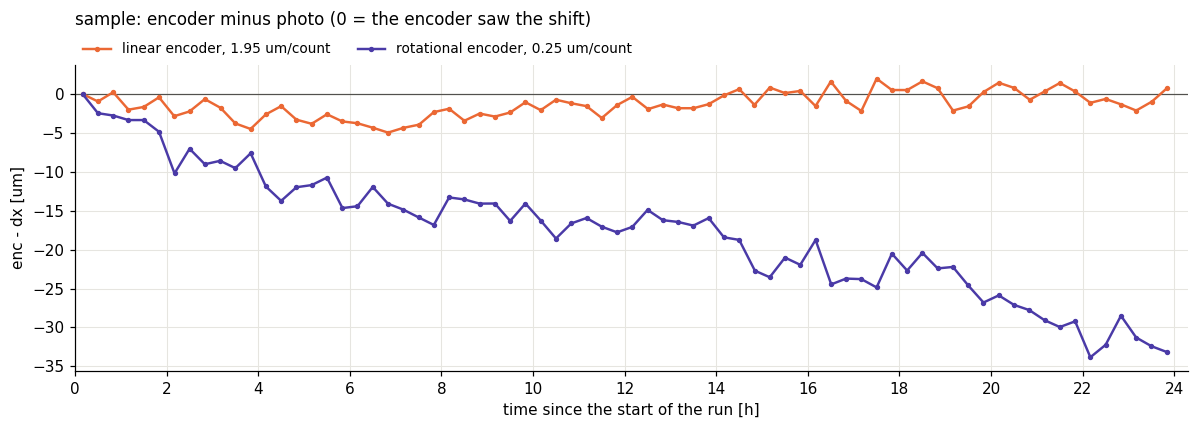

In [6]:
for place in PLACES:
    fig, ax = new_plot(f"{place}: encoder minus photo (0 = the encoder saw the shift)",
                       "enc - dx [um]")
    for name, run in runs.items():
        p = run[place]
        ax.plot(p["hours"], p["enc"] - p["dx"], ".-", color=COLOR[name],
                label=f"{name} encoder, {abs(run['um_per_count']):g} um/count")
    finish(fig, ax, f"3_encoder_minus_photo_{place}")

## 4. More

### 4.1 What the compensation saw

The encoder on arrival, before any correction, against the first arrival at the place
(`encDriftCounts` of the run, in um). This is the number the test compares with the
zone; the circles are the visits where it was outside and X was corrected. The visits
with lost steps are left out (thousands of counts off, they are the green lines of
part 1).

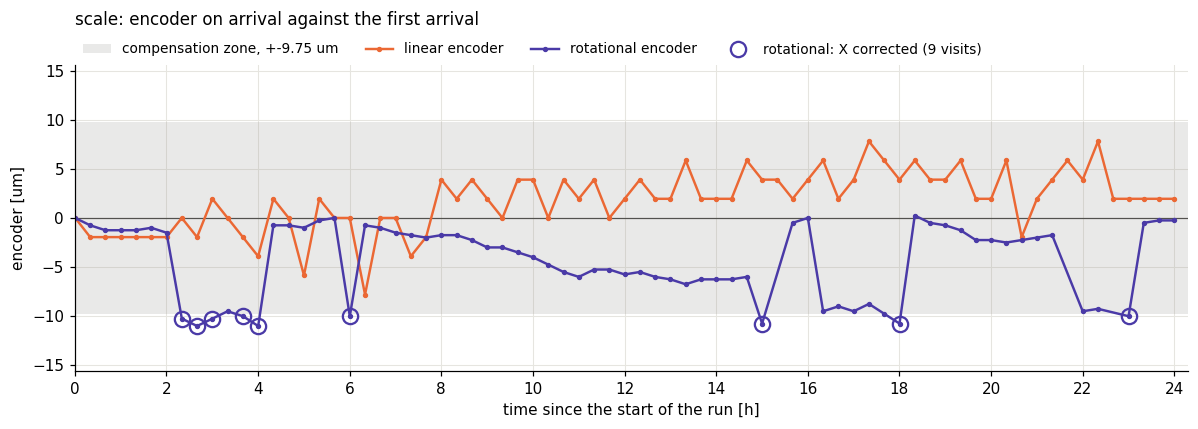

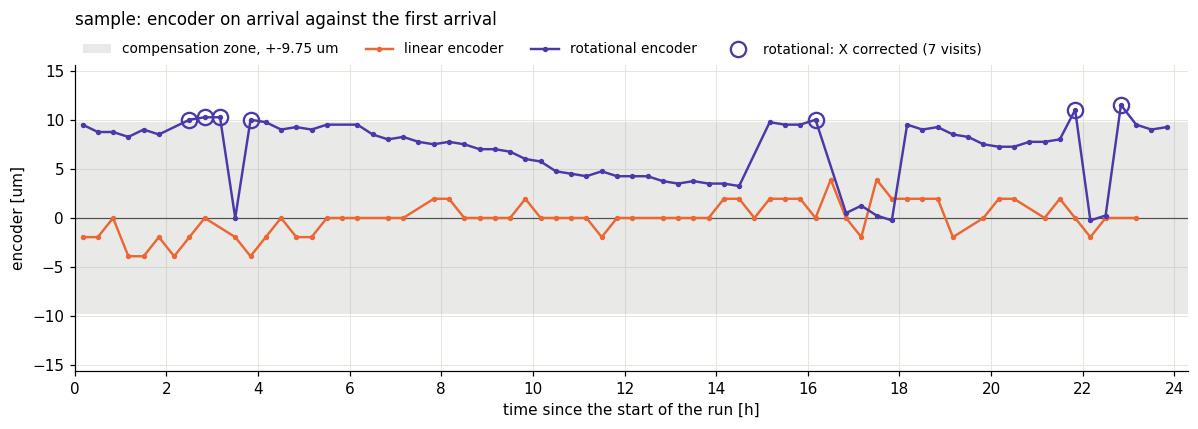

In [ ]:
for place in PLACES:
    fig, ax = new_plot(f"{place}: encoder on arrival against the first arrival", "encoder [um]")
    ax.axhspan(-zone, zone, color=COLOR["zone"], alpha=0.18, lw=0,
               label=f"compensation zone, +-{zone:.2f} um")
    for name, run in runs.items():
        p = run[place]
        keep, comp = ~p["event"], p["comp"]
        ax.plot(p["hours"][keep], p["drift"][keep], ".-", color=COLOR[name], label=f"{name} encoder")
        if comp.any():
            ax.plot(p["hours"][comp], p["drift"][comp], "o", mfc="none", mec=COLOR[name], ms=10,
                    mew=1.5, label=f"{name}: X corrected ({comp.sum()} visits)")
    ax.set_ylim(-1.6 * zone, 1.6 * zone)
    finish(fig, ax, f"4_compensation_{place}")

### 4.2 Where does the unseen shift come from?

`enc - dx` of part 3 again, one plot per encoder, with the lost-step events. A step
at a green line = the recovery left the stage at another place than the encoder
thinks; a slope between the lines = slow drift (temperature) the encoder cannot see.

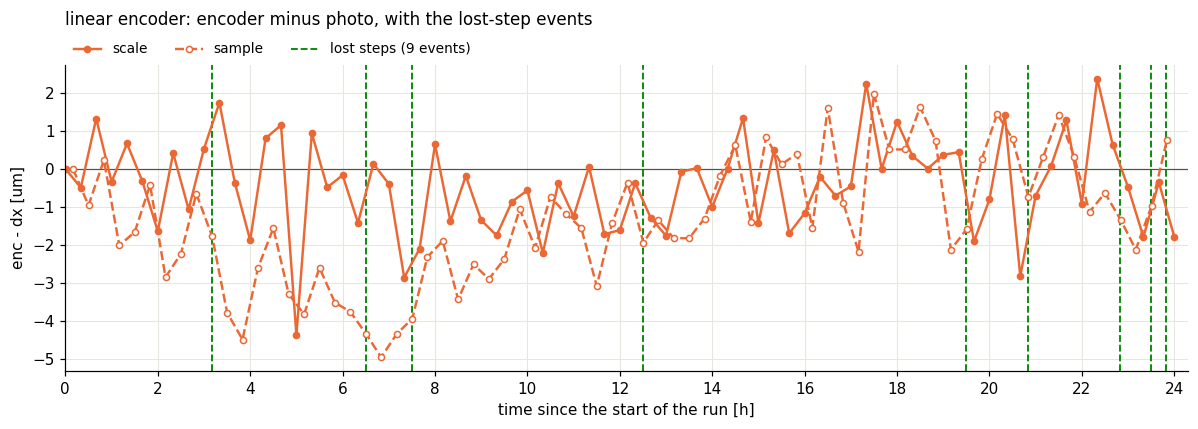

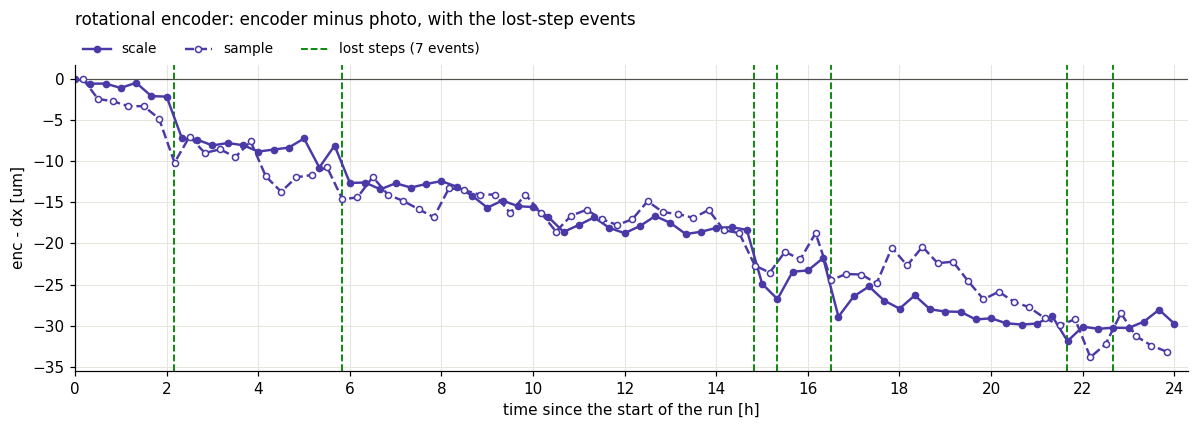

In [8]:
for name, run in runs.items():
    fig, ax = new_plot(f"{name} encoder: encoder minus photo, with the lost-step events",
                       "enc - dx [um]")
    for place, style in zip(PLACES, (dict(ls="-"), dict(ls="--", mfc="white"))):
        p = run[place]
        ax.plot(p["hours"], p["enc"] - p["dx"], "o", color=COLOR[name], ms=4, label=place, **style)
    mark_lost(ax, run)
    finish(fig, ax, f"4_unseen_shift_{name}")

### 4.3 Numbers

`at lost` = rms change of `enc - dx` between two photos of a place with a lost-step
event of the run in between, `else` = the same for all other pairs of photos.
`lost` = events on the way to this place, `corr.` = visits where X was corrected
because the encoder was out of the zone.

In [9]:
def rms(v):
    return f"{np.sqrt((v ** 2).mean()):.2f}" if v.size else "-"


print(f"{'[um]':<18} {'dx min':>7} {'dx max':>7} {'dx end':>7} {'dy min':>7} {'dy max':>7}   "
      f"{'enc - dx: rms':>13} {'end':>7} {'at lost':>8} {'else':>6}   {'lost':>4} {'corr.':>5}")
for name, run in runs.items():
    t = np.array([e["hours"] for e in run["lost"]])
    for place in PLACES:
        p = run[place]
        unseen = p["enc"] - p["dx"]
        step = np.diff(unseen)
        across = np.array([((t > a) & (t <= b)).any() for a, b in zip(p["hours"], p["hours"][1:])])
        print(f"{name:<10} {place:<7} {p['dx'].min():>7.2f} {p['dx'].max():>7.2f} {p['dx'][-1]:>7.2f} "
              f"{p['dy'].min():>7.2f} {p['dy'].max():>7.2f}   {rms(unseen):>13} {unseen[-1]:>7.2f} "
              f"{rms(step[across]):>8} {rms(step[~across]):>6}   "
              f"{sum(e['place'] == place for e in run['lost']):>4} {p['comp'].sum():>5}")

[um]                dx min  dx max  dx end  dy min  dy max   enc - dx: rms     end  at lost   else   lost corr.
linear     scale     -6.39    6.05    3.73   -1.79    0.00            1.30   -1.78     1.52   1.85      0     0
linear     sample    -0.29    6.90    1.19   -1.42    0.00            2.12    0.76     1.14   1.43      9     0
rotational scale     -1.68   33.38   29.51   -1.91    1.50           20.22  -29.76     4.67   1.16      3     9
rotational sample    -2.47   32.91   32.91   -1.46    2.09           19.46  -33.16     4.02   1.83      4     7
